# Lab 7 — OFDM: From the IFFT to the 5G NR Resource Grid

**Companion to Chapter 7.** Objectives:

1. Show how the cyclic prefix turns a frequency-selective channel into parallel
   flat subchannels with one-tap equalization.
2. Break it on purpose: CP shorter than the delay spread, CFO and Doppler (ICI).
3. Estimate the channel from comb pilots and measure the cost of imperfect CSI.
4. Compare PAPR of CP-OFDM with DFT-s-OFDM (NR/6G uplink) and single-carrier.
5. Work with NR numerologies from 3GPP TS 38.211.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import commlib as cl

cl.style()
rng = np.random.default_rng(7)
q16 = cl.get_constellation("16qam")

## 1. One-tap equalization thanks to the cyclic prefix
With a CP at least as long as the channel memory, the received subcarrier $k$ is
$Y_k = H_k X_k + W_k$, where $H_k$ is the channel DFT. We use the LTE EVA profile
at 15.36 MS/s (up to 2.51 µs of delay ≈ 39 samples) with a 64-sample CP.

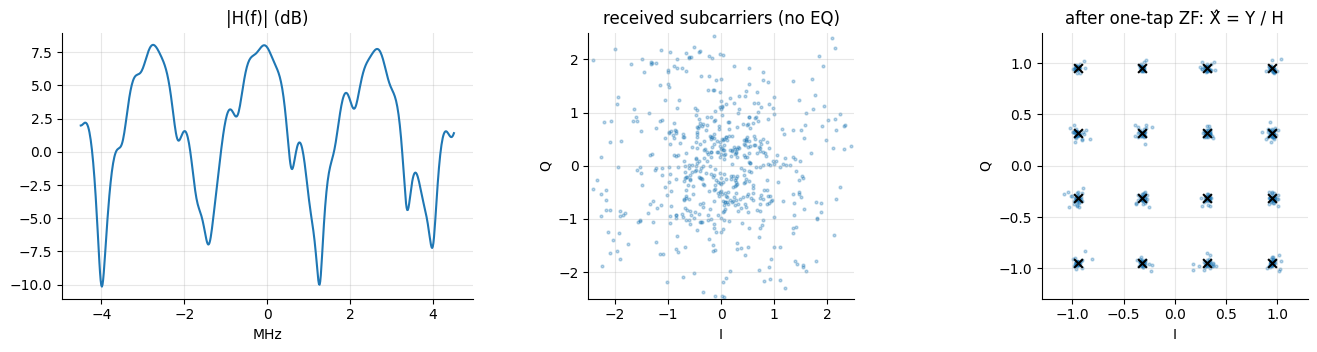

In [3]:
cfg = cl.OFDMConfig(nfft=1024, n_used=600, ncp=72)
nsym = 14
grid = q16.modulate(cl.random_bits(4 * 600 * nsym, rng)).reshape(nsym, 600)
x = cl.ofdm_modulate(grid, cfg)
fs = 15.36e6
y, taps = cl.tdl_channel(x, fs, "EVA", fd_hz=5, rng=rng, return_taps=True)
y = cl.awgn(y[:len(x)], 30, rng)
Y = cl.ofdm_demodulate(y, cfg)
H = np.fft.fft(taps[cfg.ncp], cfg.nfft)[cfg.active]       # channel at first symbol
Z = Y / H
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(cfg.k * fs / cfg.nfft / 1e6, 20 * np.log10(np.abs(H))); ax[0].set_xlabel("MHz"); ax[0].set_title("|H(f)| (dB)")
cl.plot_constellation(ax[1], Y[0], title="received subcarriers (no EQ)", lim=2.5)
cl.plot_constellation(ax[2], Z[0], q16.points, "after one-tap ZF: X̂ = Y / H")
plt.tight_layout(); plt.show()

### Interactive: cyclic prefix versus delay spread
Shrink the CP below the channel's maximum excess delay and watch inter-symbol and
inter-carrier interference raise the EVM floor even at high SNR.

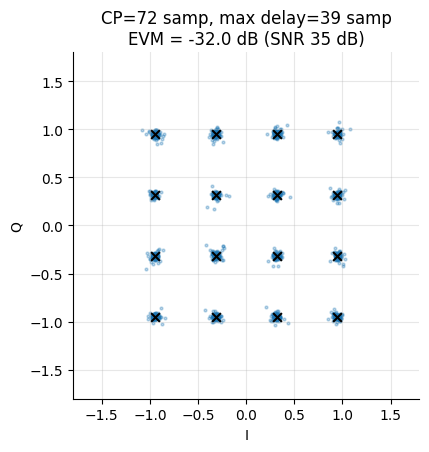

In [5]:
def cp_demo(ncp=72, profile="EVA", snr_db=35.0):
    c = cl.OFDMConfig(1024, 600, ncp)
    g = q16.modulate(cl.random_bits(4 * 600 * 8, rng)).reshape(8, 600)
    xx = cl.ofdm_modulate(g, c)
    yy, tp = cl.tdl_channel(xx, fs, profile, fd_hz=1, rng=rng, return_taps=True)
    yy = cl.awgn(yy[:len(xx)], snr_db, rng)
    YY = cl.ofdm_demodulate(yy, c)
    HH = np.array([np.fft.fft(tp[s * c.sym_len + ncp], 1024)[c.active] for s in range(8)])
    ZZ = YY[1:] / HH[1:]
    evm = 10 * np.log10(np.mean(np.abs(ZZ - g[1:]) ** 2))
    maxd = cl.TDL_PROFILES[profile][0][-1] * 1e-9 * fs
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    cl.plot_constellation(ax, ZZ.ravel()[:4000], q16.points,
                          f"CP={ncp} samp, max delay={maxd:.0f} samp\nEVM = {evm:.1f} dB (SNR {snr_db:.0f} dB)", lim=1.8)
    plt.show()

interact(cp_demo, ncp=IntSlider(value=72, min=0, max=128, step=4),
         profile=Dropdown(options=["EPA", "EVA", "ETU"], value="EVA"),
         snr_db=FloatSlider(value=35, min=10, max=45, step=1));

## 2. Carrier frequency offset destroys orthogonality
A CFO of $\epsilon$ subcarrier spacings rotates every subcarrier by a common phase
and leaks energy into neighbours. The signal-to-ICI ratio is roughly
$\mathrm{SIR} \approx 3/(\pi\epsilon)^2$ for small $\epsilon$, so 1% of the spacing
already limits SIR to about 35 dB. Doppler spread does the same, which is why NR
uses wider spacing (30–120 kHz) in high-mobility and mmWave deployments.

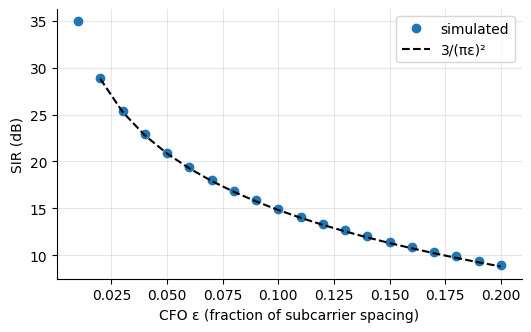

In [7]:
eps = np.linspace(0.01, 0.2, 20)
cfgS = cl.OFDMConfig(256, 200, 16)
g = q16.modulate(cl.random_bits(4 * 200 * 20, rng)).reshape(20, 200)
xs = cl.ofdm_modulate(g, cfgS)
sir = []
for e in eps:
    Ys = cl.ofdm_demodulate(cl.apply_cfo(xs, e / 256), cfgS)
    Ys = Ys * np.exp(-1j * np.angle(np.sum(Ys * np.conj(g), axis=1, keepdims=True)))  # remove common phase
    sir.append(10 * np.log10(1 / np.mean(np.abs(Ys - g) ** 2)))
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(eps, sir, "o", label="simulated"); ax.plot(eps[1:], 10 * np.log10(3 / (np.pi * eps[1:]) ** 2), "k--", label="3/(πε)²")
ax.set_xlabel("CFO ε (fraction of subcarrier spacing)"); ax.set_ylabel("SIR (dB)"); ax.legend(); plt.show()

## 3. Timing and CFO acquisition: the Schmidl & Cox preamble
A training symbol with two identical halves produces a plateau in
$M(d) = |P(d)|^2/R(d)^2$ and the phase of $P$ gives the fractional CFO.

timing metric peak at 300 (preamble starts at 300); CFO estimate +0.00170 vs true +0.00170 cycles/sample


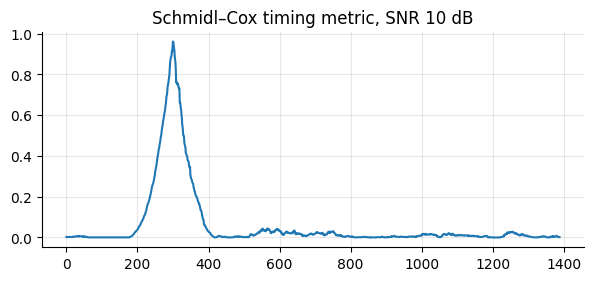

In [9]:
L = 128
half = np.exp(2j * np.pi * rng.random(L))
pre = np.concatenate([half, half])
sig = np.concatenate([np.zeros(300), pre, cl.ofdm_modulate(g[:4], cfgS)])
true_cfo = 0.0017
r = cl.awgn(cl.apply_cfo(sig, true_cfo), 10, rng)
M, P = cl.schmidl_cox_metric(r, L)
d = int(np.argmax(M))
print(f"timing metric peak at {d} (preamble starts at 300); CFO estimate "
      f"{np.angle(P[d])/(2*np.pi*L):+.5f} vs true {true_cfo:+.5f} cycles/sample")
fig, ax = plt.subplots(figsize=(7, 2.8)); ax.plot(M); ax.set_title("Schmidl–Cox timing metric, SNR 10 dB"); plt.show()

## 4. Pilot-based channel estimation
NR embeds DM-RS pilots in the resource grid. Here: comb pilots every $\Delta_f$
subcarriers on every symbol, least-squares estimates at the pilots and linear
interpolation between them. Too sparse a comb fails when
$\Delta_f \cdot \Delta f_{sc} > B_c$ (the coherence bandwidth).

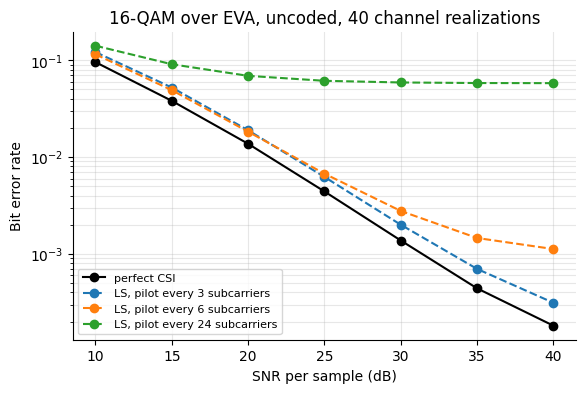

In [11]:
def ber_ofdm(snr_db, spacing, profile="EVA", perfect=False, frames=40, nsym=4):
    """Average over `frames` independent channel realizations. The channel and data
    for frame i are generated from seed i, so every estimator sees identical channels."""
    c = cl.OFDMConfig(1024, 600, 72)
    errs = total = 0
    for i in range(frames):
        r = np.random.default_rng(i)
        g = q16.modulate(cl.random_bits(4 * 600 * nsym, r)).reshape(nsym, 600)
        mask = cl.comb_pilot_mask(nsym, 600, spacing)
        pil = q16.points[0] * np.ones_like(g); g = np.where(mask, pil, g)
        xx = cl.ofdm_modulate(g, c)
        yy, tp = cl.tdl_channel(xx, fs, profile, fd_hz=5, rng=r, return_taps=True)
        yy, n0 = cl.awgn_esn0(yy[:len(xx)], snr_db, rng=r, es=np.mean(np.abs(xx) ** 2))
        YY = cl.ofdm_demodulate(yy, c)
        Htrue = np.array([np.fft.fft(tp[s * c.sym_len + 72], 1024)[c.active] for s in range(nsym)])
        Hh = Htrue if perfect else cl.ls_channel_estimate(YY, pil, mask)
        Z = YY / Hh
        e = q16.demodulate(g[~mask]) != q16.demodulate(Z[~mask])
        errs += e.sum(); total += e.size
    return errs / total

snrs = np.arange(10, 41, 5)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(snrs, [max(ber_ofdm(s, 6, perfect=True), 1e-6) for s in snrs], "k-o", label="perfect CSI")
for sp in [3, 6, 24]:
    ax.semilogy(snrs, [max(ber_ofdm(s, sp), 1e-6) for s in snrs], "o--", label=f"LS, pilot every {sp} subcarriers")
cl.ber_axes(ax, "SNR per sample (dB)"); ax.legend(fontsize=8)
ax.set_title("16-QAM over EVA, uncoded, 40 channel realizations"); plt.show()

Uncoded BER over a frequency-selective Rayleigh channel falls only as 1/SNR: the
deeply faded subcarriers dominate. Coding across subcarriers (Chapters 8–9) is what
recovers frequency diversity; this is why OFDM is never deployed without FEC.
Sparse pilots add an error floor once interpolation cannot follow the channel.

## 5. PAPR: why the uplink uses DFT-spread OFDM
CP-OFDM's time samples are nearly Gaussian, so its peaks are ~8–10 dB above the
mean at the $10^{-3}$ CCDF point. DFT precoding (SC-FDMA / DFT-s-OFDM) restores a
single-carrier envelope and saves several dB of PA back-off. NR supports it in
the uplink and the 6G study keeps it, now including uplink MIMO.

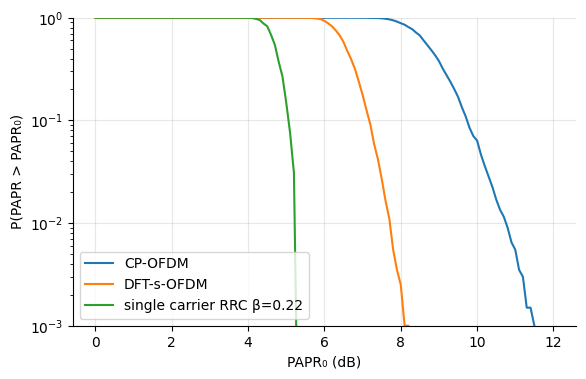

In [14]:
cfgP = cl.OFDMConfig(512, 300, 0)
qp = cl.get_constellation("qpsk")
sym = qp.modulate(cl.random_bits(2 * 300 * 2000, rng))
x_ofdm = cl.ofdm_modulate(sym.reshape(-1, 300), cfgP)
x_dfts = cl.dft_s_ofdm_modulate(sym, cfgP)
os_x = lambda x: np.fft.ifft(np.fft.fft(x.reshape(-1, 512), axis=1), 2048, axis=1).ravel()  # 4x oversample
h = cl.rrc_taps(0.22, 4, 10)
x_sc = cl.shape(sym[:300 * 500], h, 4)
fig, ax = plt.subplots(figsize=(6.5, 4))
for nm, xx, L in [("CP-OFDM", os_x(x_ofdm), 2048), ("DFT-s-OFDM", os_x(x_dfts), 2048), ("single carrier RRC β=0.22", x_sc[500:-500], 2048)]:
    gg, cc = cl.ccdf(cl.papr_db(xx, L), np.linspace(0, 12, 121))
    ax.semilogy(gg, np.maximum(cc, 1e-4), label=nm)
ax.set_xlabel("PAPR₀ (dB)"); ax.set_ylabel("P(PAPR > PAPR₀)"); ax.set_ylim(1e-3, 1); ax.legend(); plt.show()

## 6. 5G NR numerology
Subcarrier spacing $15\cdot 2^\mu$ kHz, 14 symbols per slot (normal CP), a slot of
$1/2^\mu$ ms, and 12 subcarriers per resource block.

In [16]:
print(f"{'μ':>2} {'SCS kHz':>8} {'slot ms':>8} {'symbol µs':>10} {'CP µs':>7} {'RB kHz':>7}")
for mu in range(0, 7):
    d = cl.nr_numerology(mu)
    print(f"{mu:>2} {d['scs_khz']:8.0f} {d['slot_ms']:8.4f} {d['useful_symbol_us']:10.3f} {d['cp_us']:7.3f} {d['rb_bandwidth_khz']:7.0f}")

 μ  SCS kHz  slot ms  symbol µs   CP µs  RB kHz
 0       15   1.0000     66.667   4.688     180
 1       30   0.5000     33.333   2.344     360
 2       60   0.2500     16.667   1.172     720
 3      120   0.1250      8.333   0.586    1440
 4      240   0.0625      4.167   0.293    2880
 5      480   0.0312      2.083   0.146    5760
 6      960   0.0156      1.042   0.073   11520


## Exercises
1. **(Warm-up)** Prove that circular convolution becomes multiplication in the DFT
   domain, and show why a CP of length ≥ L−1 makes linear convolution circular.
2. **(Core)** Replace the LS estimator with LMMSE interpolation in frequency using the
   channel's frequency correlation $R_{HH}$ (exponential PDP assumption). Plot the gain.
3. **(Core)** Add a Doppler of 5%, 10% and 20% of the subcarrier spacing using
   `tdl_channel` and measure the ICI floor. Compare with your answer to Lab 5 Ex. 2.
4. **(Stretch)** Implement clipping-and-filtering PAPR reduction and plot the trade-off
   between PAPR at the 10⁻³ point, EVM and out-of-band emission.